## CROMA per-pixel embeddings

Extract **spatially resolved** embeddings from CROMA (not GAP-pooled).

CROMA uses 8×8 patches and accepts any input whose dimensions are a multiple of 8,
producing a **15×15 grid of 768‑dim tokens**.  
Each token represents an **80 m × 80 m** area (8 px × 10 m/px).

This notebook:
1. Loads 120×120 tiles (already a multiple of 8, no cropping needed)
2. Extracts the 15×15 patch token grid (before GAP) in a single forward pass
3. Visualizes per-patch embeddings as spatial maps (PCA / similarity)
4. Supports optical, radar, and joint modes

In [2]:
import os
import glob
import numpy as np
import torch
import rasterio
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from pathlib import Path
from sklearn.decomposition import PCA
from torchgeo.models import croma_base, CROMABase_Weights

# ── Configuration ──
SCRIPT_DIR = os.path.dirname(os.path.abspath("__file__"))

if os.path.exists(os.path.expanduser("~/thesis_tiles_120px")):
    TILES_DIR = os.path.expanduser("~/thesis_tiles_120px")
    SHP_DIR = os.path.join(SCRIPT_DIR, "data_shp")
else:
    TILES_DIR = "/Users/angelicamariamorenorojas/Desktop/Master/thesis/tiles_120px"
    SHP_DIR = os.path.join(SCRIPT_DIR, "data_shp")

PATCH_SIZE = 8
EMBED_DIM = 768
TILE_SIZE = 120
GRID_SIZE = TILE_SIZE // PATCH_SIZE
CROMA_S2_BAND_INDICES = list(range(12))

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")
print(f"Device: {device}")
print(f"Tiles dir: {TILES_DIR}")
print(f"CROMA: {TILE_SIZE}x{TILE_SIZE} -> {GRID_SIZE}x{GRID_SIZE} patch grid -> {EMBED_DIM}-dim tokens")


/opt/anaconda3/envs/geo_latest/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps
Tiles dir: /Users/angelicamariamorenorojas/Desktop/Master/thesis/tiles_120px
CROMA: 120x120 -> 15x15 patch grid -> 768-dim tokens


## 1. Helper functions: loading, normalization, cropping

In [3]:
def normalize(x):
    """Per-channel normalization to [0, 1] using μ ± 2σ window.
    μ and σ are computed FROM x — so the normalization scope = whatever batch
    you pass in. Pass N tiles together to normalize them with shared stats."""
    x = x.float()
    imgs = []
    for ch in range(x.shape[1]):
        channel = x[:, ch, :, :]
        min_val = channel.mean() - 2 * channel.std()
        max_val = channel.mean() + 2 * channel.std()
        img = (channel - min_val) / (max_val - min_val + 1e-10)
        img = torch.clamp(img, 0, 1)
        imgs.append(img.unsqueeze(1))
    return torch.cat(imgs, dim=1)


def load_tile(tif_path, band_indices=None):
    with rasterio.open(tif_path) as src:
        data = src.read().astype(np.float32)
        transform = src.transform
        crs = src.crs
    if band_indices is not None:
        data = data[band_indices]
    return data, transform, crs


def find_sample_tile(fid, product, window="evt"):
    pattern = os.path.join(TILES_DIR, product, f"fid_{fid}", window, "*", "tile_0.tif")
    tifs = sorted(glob.glob(pattern))
    return tifs[0] if tifs else None


def list_available_fids():
    s2_dir = os.path.join(TILES_DIR, "s2_l2a")
    s1_dir = os.path.join(TILES_DIR, "s1_grd")
    if not os.path.exists(s2_dir) or not os.path.exists(s1_dir):
        return []
    s2_fids = {d.replace("fid_", "") for d in os.listdir(s2_dir) if d.startswith("fid_")}
    s1_fids = {d.replace("fid_", "") for d in os.listdir(s1_dir) if d.startswith("fid_")}
    return sorted(s2_fids & s1_fids)


available_fids = list_available_fids()
print(f"FIDs with both S2 L2A and S1 GRD: {len(available_fids)}")
if available_fids:
    print(f"Examples: {available_fids[:10]}")


FIDs with both S2 L2A and S1 GRD: 0


## 2. Load CROMA model and extract patch tokens

In [ ]:
def load_croma_model(modalities):
    model = croma_base(
        weights=CROMABase_Weights.CROMA_VIT,
        modalities=modalities,
        image_size=TILE_SIZE,
    )
    model = model.to(device)
    model.eval()
    return model


def encode(model, x_normalized, modality):
    """Forward pass over an already-normalized batch x_normalized of shape (N, C, H, W).
    Returns tokens of shape (N, 15, 15, 768)."""
    captured = {}
    encoder = model.s2_encoder if modality == "optical" else model.s1_encoder

    def hook(module, input, output):
        captured['tokens'] = output

    h = encoder.register_forward_hook(hook)
    with torch.no_grad():
        if modality == "optical":
            _ = model(x_optical=x_normalized)
        else:
            _ = model(x_sar=x_normalized)
    h.remove()

    out = captured['tokens']
    if isinstance(out, tuple):
        out = out[0]
    tokens = out.cpu().numpy()
    if tokens.ndim == 2:
        tokens = tokens[None]
    expected = GRID_SIZE * GRID_SIZE
    if tokens.shape[1] == expected + 1:
        tokens = tokens[:, 1:]
    return tokens.reshape(-1, GRID_SIZE, GRID_SIZE, EMBED_DIM)


def extract_tile_tokens(model, tif_path, modality, band_indices=None):
    """Single-tile extraction (section 3-8). CROMA recipe with N=1.
    Same pattern as CROMA example: build tensor -> normalize -> encode."""
    data, transform, crs = load_tile(tif_path, band_indices=band_indices)
    x = torch.from_numpy(data).unsqueeze(0)        # (1, C, H, W)
    x = normalize(x).to(device)                     # stats from this one tile
    tokens = encode(model, x, modality)[0]          # (15, 15, 768)
    gap = tokens.reshape(-1, EMBED_DIM).mean(axis=0)
    return {
        'data': data, 'tokens': tokens, 'gap': gap,
        'transform': transform, 'crs': crs, 'path': tif_path,
    }


print("Functions ready: encode (forward pass), extract_tile_tokens (single-tile flow)")


## 3. Pick a sample FID and extract embeddings

In [5]:
# Choose a FID (change this to explore different polygons)
#FID = available_fids[4] if available_fids else None
FID = 153
print(f"Using FID: {FID}")

# Find tiles for all 3 windows
s2_tiles = {}
s1_tiles = {}
for window in ["evt", "bef", "aft"]:
    s2_path = find_sample_tile(FID, "s2_l2a", window)
    s1_path = find_sample_tile(FID, "s1_grd", window)
    if s2_path:
        s2_tiles[window] = s2_path
        print(f"  S2 {window}: {Path(s2_path).parent.name}")
    if s1_path:
        s1_tiles[window] = s1_path
        print(f"  S1 {window}: {Path(s1_path).parent.name}")

Using FID: 153


In [6]:
model_opt = load_croma_model(['optical'])                                                                                  
# Print all attributes                                                                                                     
print([a for a in dir(model_opt) if not a.startswith('_')])
print("\nNamed children:")                                                                                                 
for name, module in model_opt.named_children():                                                                            
  print(f"  {name}: {type(module).__name__}")   

['T_destination', 'add_module', 'apply', 'attn_bias', 'bfloat16', 'buffers', 'call_super_init', 'children', 'compile', 'cpu', 'cuda', 'double', 'dump_patches', 'encoder_depth', 'encoder_dim', 'eval', 'extra_repr', 'float', 'forward', 'get_buffer', 'get_extra_state', 'get_parameter', 'get_submodule', 'half', 'image_size', 'ipu', 'load_state_dict', 'modalities', 'modules', 'mtia', 'named_buffers', 'named_children', 'named_modules', 'named_parameters', 'num_heads', 'num_patches', 'parameters', 'patch_size', 'register_backward_hook', 'register_buffer', 'register_forward_hook', 'register_forward_pre_hook', 'register_full_backward_hook', 'register_full_backward_pre_hook', 'register_load_state_dict_post_hook', 'register_load_state_dict_pre_hook', 'register_module', 'register_parameter', 'register_state_dict_post_hook', 'register_state_dict_pre_hook', 'requires_grad_', 's1_channels', 's2_GAP_FFN', 's2_channels', 's2_encoder', 'set_extra_state', 'set_submodule', 'share_memory', 'state_dict', 't

In [7]:
# Load and extract optical tokens for the full tile (single forward pass)
print("Loading optical model...")
model_opt = load_croma_model(['optical'])

optical_results = {}
for window, path in s2_tiles.items():
    result = extract_tile_tokens(model_opt, path, modality="optical", band_indices=CROMA_S2_BAND_INDICES)
    optical_results[window] = result
    print(f"  {window}: {result['data'].shape} -> tokens {result['tokens'].shape}, gap norm={np.linalg.norm(result['gap']):.2f}")

del model_opt
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Done.")

Loading optical model...
Done.


the mean of the value of the embeddings per one image before and after are similar, but this is global, no inside the polygon.

## 4. Visualize: PCA of patch tokens as spatial maps

Project the 768‑dim tokens to 3 principal components and display as RGB.  
Each pixel in the 15×15 map represents an 80 m × 80 m patch.

In [8]:
# Load polygon for overlay
import geopandas as gpd

#Upload the polygons
shp_path = os.path.join(SHP_DIR, "label_polygons.shp")
if os.path.exists(shp_path):
    gdf = gpd.read_file(shp_path)
    gdf["fid"] = gdf["fid"].astype(int).astype(str)  # 1.0 -> "1"
    print(f"Loaded {len(gdf)} polygons")
else:
    gdf = None
    print(f"Shapefile not found at {shp_path}")

# Calculate the polygon from regualr coordinates to column and row
def get_polygon_pixels(fid, transform, crs):
    """Get polygon boundary in pixel coordinates."""
    if gdf is None:
        return None
    poly_row = gdf[gdf["fid"] == str(fid)]
    if poly_row.empty:
        return None
    poly_reproj = poly_row.to_crs(crs)
    coords_list = []
    for geom in poly_reproj.geometry:
        if geom.is_empty:
            continue
        geoms = [geom] if geom.geom_type == "Polygon" else list(geom.geoms)
        for g in geoms:
            xs, ys = g.exterior.coords.xy
            pixel_coords = [(~transform * (x, y)) for x, y in zip(xs, ys)]
            coords_list.append(pixel_coords)
    # return a list of tuples (column, row) of each close border
    return coords_list

# Graphical representation of the polygon in pixels representation -> per representation in 120 x 120
def add_polygon_overlay(ax, fid, transform, crs, img_size=None):
    """Add polygon outline at native pixel scale."""
    coords_list = get_polygon_pixels(fid, transform, crs)
    if coords_list:
        for coords in coords_list:
            poly_patch = MplPolygon(coords, closed=True,
                                    edgecolor="red", facecolor="red", alpha=0.2, linewidth=2)
            ax.add_patch(poly_patch)

# Graphical representation of the polygon in pixels representation -> per representation in 15 x 15
def add_polygon_overlay_on_grid(ax, fid, transform, crs, scale_factor):
    """Add polygon outline scaled to a downsampled grid (e.g. token grid)."""
    coords_list = get_polygon_pixels(fid, transform, crs)
    if coords_list:
        for coords in coords_list:
            #this is the difference with the previous function
            scaled = [(x / scale_factor, y / scale_factor) for x, y in coords]
            poly_patch = MplPolygon(scaled, closed=True,
                                    edgecolor="red", facecolor="red", alpha=0.2, linewidth=2)
            ax.add_patch(poly_patch)

Loaded 389 polygons


In [9]:
# PCA across all windows jointly (so colors are comparable)
windows_with_data = [w for w in ["evt", "bef", "aft"] if w in optical_results]

# Stack all tokens for joint PCA fitting
all_tokens = np.concatenate(
    [optical_results[w]['tokens'].reshape(-1, EMBED_DIM) for w in windows_with_data]
)
pca = PCA(n_components=3)
pca.fit(all_tokens) # made pca per all windows no 
print(f"PCA explained variance: {pca.explained_variance_ratio_}")
print(f"Token grid shape: {optical_results[windows_with_data[0]]['tokens'].shape}")

# Plot: row 1 = RGB image (TILE_SIZE x TILE_SIZE), row 2 = PCA embedding map (token grid)
fig, axes = plt.subplots(2, len(windows_with_data), figsize=(5 * len(windows_with_data), 10))
if len(windows_with_data) == 1:
    axes = axes[:, np.newaxis]

for col, window in enumerate(windows_with_data):
    res = optical_results[window]
    data = res['data']
    tokens = res['tokens']
    transform = res['transform']
    crs = res['crs']
    th, tw = tokens.shape[:2]

    #return {                                                                                                                              
      #'data': data,            # tile crudo (12, 120, 120)
      #'tokens': tokens,        # embeddings (15, 15, 768)                                                                               
      #'gap': gap,              # vector global (768,)
      #'transform': transform,  # matriz afín de rasterio                                                                                
      #'crs': crs,              # sistema de coordenadas                                                                                 
      #'path': tif_path,        # ruta del archivo .tif                                                                                  
  #} 

    # Row 1: RGB image (B4=index 3, B3=index 2, B2=index 1)
    ax_rgb = axes[0, col]
    rgb = data[[3, 2, 1]].transpose(1, 2, 0)
    rgb = np.clip(rgb / 3000, 0, 1)
    ax_rgb.imshow(rgb)
    add_polygon_overlay(ax_rgb, FID, transform, crs, TILE_SIZE)
    ax_rgb.set_title(f"{window.upper()} — RGB ({TILE_SIZE}x{TILE_SIZE})", fontsize=10)
    ax_rgb.axis("off")

    # Row 2: PCA of patch tokens (15x15 grid)
    ax_pca = axes[1, col]
    tokens_flat = tokens.reshape(-1, EMBED_DIM)
    pca_rgb = pca.transform(tokens_flat).reshape(th, tw, 3)
    for c in range(3):
        vmin, vmax = pca_rgb[:, :, c].min(), pca_rgb[:, :, c].max()
        pca_rgb[:, :, c] = (pca_rgb[:, :, c] - vmin) / (vmax - vmin + 1e-10)
    ax_pca.imshow(pca_rgb, interpolation="nearest")
    add_polygon_overlay_on_grid(ax_pca, FID, transform, crs, PATCH_SIZE)
    ax_pca.set_title(f"{window.upper()} — PCA tokens ({th}x{tw})", fontsize=10)
    ax_pca.axis("off")

fig.suptitle(f"FID {FID} — Optical per-patch embeddings ({TILE_SIZE}x{TILE_SIZE}, single pass)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

ValueError: need at least one array to concatenate

## 5. Cosine similarity: event vs before/after

For each patch, compute cosine similarity between its event embedding and its before/after embedding.

- High similarity = no change  
- Low similarity = change detected

Par                 min       p1       p5      p50      p95      max      mean       std
bef vs aft        0.116    0.127    0.173    0.595    0.880    0.961     0.556     0.202

Rango común para la visualización (basado en p1 de los datos):
  Cosine similarity: [0.127, 1.000]
  Change magnitude:  [0.000, 0.873]


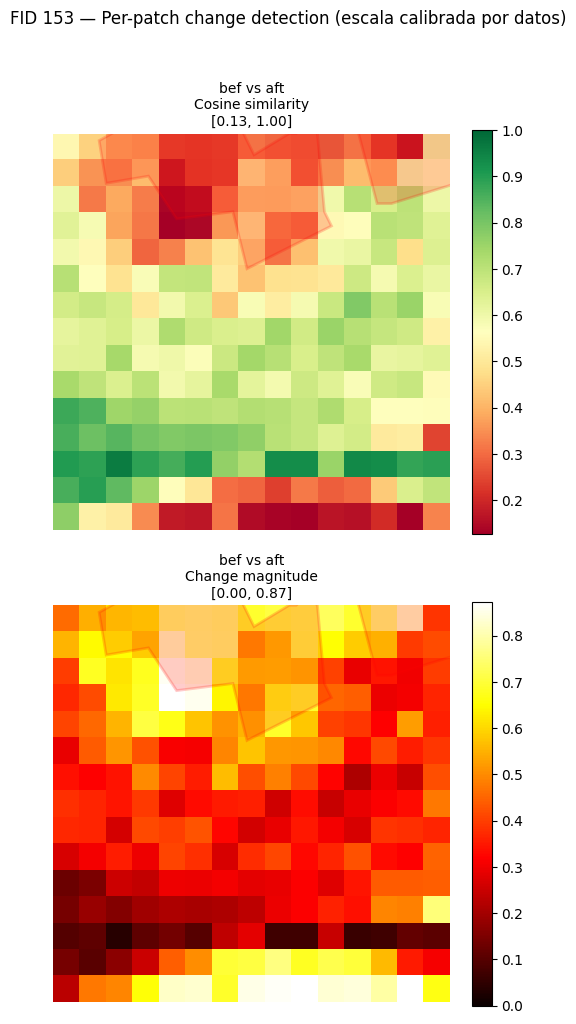

In [ ]:
def cosine_similarity_map(tokens_a, tokens_b):
    """Per-patch cosine similarity between two token grids.
    Returns: (H, W) array of similarities in [-1, 1].
    """
    h, w = tokens_a.shape[:2] # save 15 x 15
    a = tokens_a.reshape(-1, EMBED_DIM) # flat to 225, 768 to window A (ex before)
    b = tokens_b.reshape(-1, EMBED_DIM) # flat to 225, 768 to window B (ex event)
    a_norm = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-10) # normalize the vector to unit length
    b_norm = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-10) 
    return (a_norm * b_norm).sum(axis=1).reshape(h, w) # dot product and come back to (15 x 15)
    #this return is a 15 x 15 matrix with values between -1 and 1
    
#print(cosine_similarity_map(optical_results[w1]['tokens'], optical_results[w2]['tokens']))

# ─── Pares de ventanas a comparar ───                                                                                                
pairs = []      
if "evt" in optical_results and "bef" in optical_results:                                                                             
    pairs.append(("evt", "bef"))
if "evt" in optical_results and "aft" in optical_results:                                                                             
    pairs.append(("evt", "aft"))
if "bef" in optical_results and "aft" in optical_results:                                                                             
    pairs.append(("bef", "aft"))                                                                                                      

if not pairs:                                                                                                                         
    print("No hay suficientes ventanas para comparar.")
else:
    # ─── PASE 1: calcular todas las matrices y resumir estadísticas ───                                                              
    sims = {}                                                                                                                         
    print("="*78)                                                                                                                     
    print(f"{'Par':<14} {'min':>8} {'p1':>8} {'p5':>8} {'p50':>8} {'p95':>8} {'max':>8}  {'mean':>8}  {'std':>8}")                    
    print("="*78)                                                                                                                     
    for w1, w2 in pairs:
        sim = cosine_similarity_map(                                                                                                  
            optical_results[w1]['tokens'],
            optical_results[w2]['tokens']                                                                                             
        )       
        sims[(w1, w2)] = sim                                                                                                          
        print(f"{w1+' vs '+w2:<14} "
                f"{sim.min():>8.3f} "                                                                                                   
                f"{np.percentile(sim, 1):>8.3f} "
                f"{np.percentile(sim, 5):>8.3f} "                                                                                       
                f"{np.percentile(sim, 50):>8.3f} "                                                                                      
                f"{np.percentile(sim, 95):>8.3f} "
                f"{sim.max():>8.3f}  "                                                                                                  
                f"{sim.mean():>8.3f}  "                                                                                                 
                f"{sim.std():>8.3f}")
                                                                                                                                        
    # ─── Decidir vmin/vmax a partir de los datos ───                                                                                 
    # Usamos percentil 1 como vmin para no dejar que un outlier domine la escala,
    # y 1.0 como vmax (siempre tiene sentido como "100% similar = sin cambio").                                                       
    all_values = np.concatenate([s.flatten() for s in sims.values()])                                                                 
    vmin_sim = float(np.percentile(all_values, 1))                                                                                    
    vmax_sim = 1.0                                                                                                                    
    # Para "change magnitude" (1 - sim), los límites se invierten
    vmin_change = 1 - vmax_sim                                                                                                        
    vmax_change = 1 - vmin_sim                                                                                                        
                                                                                                                                        
    print(f"\nRango común para la visualización (basado en p1 de los datos):")                                                        
    print(f"  Cosine similarity: [{vmin_sim:.3f}, {vmax_sim:.3f}]")
    print(f"  Change magnitude:  [{vmin_change:.3f}, {vmax_change:.3f}]")                                                             
                                                                                                                                        
    # ─── PASE 2: visualizar con los límites calibrados ───                                                                           
    n_comp = len(pairs)                                                                                                               
    fig, axes = plt.subplots(2, n_comp, figsize=(5 * n_comp, 10))                                                                     
    if n_comp == 1:                                                                                                                   
        axes = axes[:, np.newaxis]                                                                                                    
                                                                                                                                        
    for col, (w1, w2) in enumerate(pairs):
        sim = sims[(w1, w2)]                                                                                                          
        transform = optical_results[w1]['transform']
        crs = optical_results[w1]['crs']                                                                                              
        title = f"{w1} vs {w2}"
                                                                                                                                        
        # Fila 1: similitud
        ax = axes[0, col]                                                                                                             
        im = ax.imshow(sim, cmap="RdYlGn", vmin=vmin_sim, vmax=vmax_sim,
                        interpolation="nearest")                                                                                       
        add_polygon_overlay_on_grid(ax, FID, transform, crs, PATCH_SIZE)                                                              
        ax.set_title(f"{title}\nCosine similarity\n[{vmin_sim:.2f}, {vmax_sim:.2f}]",                                                 
                    fontsize=10)                                                                                                     
        ax.axis("off")                                                                                                                
        plt.colorbar(im, ax=ax, fraction=0.046)
                                                                                                                                        
        # Fila 2: magnitud de cambio                                                                                                  
        ax2 = axes[1, col]
        change = 1 - sim                                                                                                              
        im2 = ax2.imshow(change, cmap="hot", vmin=vmin_change, vmax=vmax_change,
                        interpolation="nearest")                                                                                     
        add_polygon_overlay_on_grid(ax2, FID, transform, crs, PATCH_SIZE)
        ax2.set_title(f"{title}\nChange magnitude\n[{vmin_change:.2f}, {vmax_change:.2f}]",                                           
                        fontsize=10)                                                                                                    
        ax2.axis("off")                                                                                                               
        plt.colorbar(im2, ax=ax2, fraction=0.046)                                                                                     
                
    fig.suptitle(f"FID {FID} — Per-patch change detection (escala calibrada por datos)",                                              
                fontsize=12, y=1.02)
    plt.tight_layout()                                                                                                                
    plt.show()

In [ ]:
# Pair per window                                                                                  
pairs = []                                                                                                                            
if "evt" in optical_results and "bef" in optical_results:
    pairs.append(("evt", "bef"))                                                                                                      
if "evt" in optical_results and "aft" in optical_results:
    pairs.append(("evt", "aft"))                                                                                                      
if "bef" in optical_results and "aft" in optical_results:
    pairs.append(("bef", "aft"))                                                                                                      

print(pairs)

[('bef', 'aft')]


In [ ]:

for w1, w2 in pairs:                                                                                                                  
    sim = cosine_similarity_map(
        optical_results[w1]['tokens'],                                                                                                
        optical_results[w2]['tokens']                                                                                                 
    )
                                                                                                                                    
    print(f"\n{'='*70}")                                                                                                              
    print(f"Cosine similarity: {w1} vs {w2}")
    print(f"{'='*70}")                                                                                                                
    print(f"Forma: {sim.shape}")                                                                                                      
    print(f"Estadísticas:  min={sim.min():.4f}  max={sim.max():.4f}  "
        f"mean={sim.mean():.4f}  std={sim.std():.4f}")                                                                              
    print(f"Percentiles:   p5={np.percentile(sim, 5):.4f}  "
        f"p50={np.percentile(sim, 50):.4f}  p95={np.percentile(sim, 95):.4f}")                                                      
                                                                                                                                    
    # Matriz completa con 3 decimales                                                                                                 
    print(f"\nMatriz {sim.shape[0]}×{sim.shape[1]}:")                                                                                 
    np.set_printoptions(precision=3, suppress=True, linewidth=200)                                                                    
    print(sim)  


Cosine similarity: bef vs aft
Forma: (15, 15)
Estadísticas:  min=0.1161  max=0.9606  mean=0.5564  std=0.2022
Percentiles:   p5=0.1734  p50=0.5946  p95=0.8803

Matriz 15×15:
[[0.543 0.453 0.386 0.374 0.248 0.24  0.247 0.31  0.294 0.283 0.27  0.311 0.241 0.173 0.595]
 [0.446 0.353 0.345 0.417 0.181 0.238 0.244 0.485 0.432 0.289 0.349 0.416 0.395 0.585 0.559]
 [0.603 0.319 0.385 0.323 0.14  0.158 0.312 0.428 0.425 0.438 0.596 0.709 0.651 0.7   0.604]
 [0.63  0.581 0.379 0.316 0.116 0.144 0.36  0.486 0.329 0.31  0.55  0.558 0.703 0.695 0.632]
 [0.593 0.545 0.445 0.293 0.331 0.427 0.489 0.448 0.314 0.424 0.597 0.608 0.681 0.476 0.64 ]
 [0.707 0.561 0.488 0.576 0.688 0.691 0.508 0.426 0.485 0.488 0.503 0.67  0.587 0.643 0.611]
 [0.661 0.683 0.659 0.499 0.594 0.643 0.437 0.578 0.514 0.584 0.677 0.788 0.705 0.753 0.578]
 [0.621 0.634 0.654 0.606 0.723 0.668 0.647 0.64  0.744 0.664 0.753 0.707 0.686 0.668 0.526]
 [0.63  0.633 0.736 0.585 0.599 0.571 0.674 0.739 0.707 0.649 0.694 0.733 0.614 0.

In [ ]:
print(list(optical_results.keys()))
print(list(optical_results['bef'].keys()))                                                                                            
print(f"Forma de data: {optical_results['bef']['data'].shape}")
print(f"Forma de tokens: {optical_results['bef']['tokens'].shape}")                                                                   
print(f"Forma de gap: {optical_results['bef']['gap'].shape}")
                        

['bef', 'aft']
['data', 'tokens', 'gap', 'transform', 'crs', 'path']
Forma de data: (12, 120, 120)
Forma de tokens: (15, 15, 768)
Forma de gap: (768,)


## 6. SAR + Joint embeddings (multimodal)

In [ ]:
# SAR-only embeddings (single forward pass)
print("Loading SAR model...")
model_sar = load_croma_model(['sar'])

sar_results = {}
for window, path in s1_tiles.items():
    result = extract_tile_tokens(model_sar, path, modality="sar")
    sar_results[window] = result
    print(f"  SAR {window}: tokens {result['tokens'].shape}, norm={np.linalg.norm(result['gap']):.2f}")

del model_sar
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Done.")

Loading SAR model...
  SAR evt: tokens (15, 15, 768), norm=22.32
  SAR bef: tokens (15, 15, 768), norm=22.45
  SAR aft: tokens (15, 15, 768), norm=22.76
Done.


## 7. Compare modalities: optical vs SAR vs joint change maps

In [ ]:
# Compare evt vs bef change maps across modalities (calibrated vmin/vmax)
modalities = []
if "evt" in optical_results and "bef" in optical_results:
    modalities.append(("Optical", optical_results))
if "evt" in sar_results and "bef" in sar_results:
    modalities.append(("SAR", sar_results))

n_mod = len(modalities)
if n_mod > 0:
    # ─── PASE 1: calcular sims y resumir estadísticas ───
    sims = {}
    print("=" * 78)
    print(f"{'Modality':<10} {'min':>8} {'p1':>8} {'p5':>8} {'p50':>8} {'p95':>8} {'max':>8}  {'mean':>8}")
    print("=" * 78)
    for name, results in modalities:
        sim = cosine_similarity_map(results["evt"]['tokens'], results["bef"]['tokens'])
        sims[name] = sim
        print(f"{name:<10} "
              f"{sim.min():>8.3f} "
              f"{np.percentile(sim, 1):>8.3f} "
              f"{np.percentile(sim, 5):>8.3f} "
              f"{np.percentile(sim, 50):>8.3f} "
              f"{np.percentile(sim, 95):>8.3f} "
              f"{sim.max():>8.3f}  "
              f"{sim.mean():>8.3f}")

    # Calibración GLOBAL (colores comparables entre Optical y SAR)
    all_values = np.concatenate([s.flatten() for s in sims.values()])
    vmin_sim = float(np.percentile(all_values, 1))
    vmax_sim = 1.0
    vmin_change = 1 - vmax_sim
    vmax_change = 1 - vmin_sim
    print(f"\nEscala común calibrada (p1 de los datos):")
    print(f"  Cosine similarity: [{vmin_sim:.3f}, {vmax_sim:.3f}]")
    print(f"  Change magnitude:  [{vmin_change:.3f}, {vmax_change:.3f}]")

    # ─── PASE 2: visualizar con escala calibrada ───
    fig, axes = plt.subplots(2, n_mod, figsize=(5 * n_mod, 10))
    if n_mod == 1:
        axes = axes[:, np.newaxis]

    for col, (name, results) in enumerate(modalities):
        sim = sims[name]
        transform = results["evt"]['transform']
        crs = results["evt"]['crs']

        ax = axes[0, col]
        im = ax.imshow(sim, cmap="RdYlGn", vmin=vmin_sim, vmax=vmax_sim, interpolation="nearest")
        add_polygon_overlay_on_grid(ax, FID, transform, crs, PATCH_SIZE)
        ax.set_title(f"{name}\nCosine similarity (evt vs bef)\n[{vmin_sim:.2f}, {vmax_sim:.2f}]", fontsize=10)
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046)

        ax2 = axes[1, col]
        change = 1 - sim
        im2 = ax2.imshow(change, cmap="hot", vmin=vmin_change, vmax=vmax_change, interpolation="nearest")
        add_polygon_overlay_on_grid(ax2, FID, transform, crs, PATCH_SIZE)
        ax2.set_title(f"{name}\nChange magnitude\n[{vmin_change:.2f}, {vmax_change:.2f}]", fontsize=10)
        ax2.axis("off")
        plt.colorbar(im2, ax=ax2, fraction=0.046)

    fig.suptitle(f"FID {FID} — Event vs Before: per-patch change by modality (escala calibrada)", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Need both evt and bef windows for at least one modality")


NameError: name 'optical_results' is not defined

## 8. Embedding statistics

In [ ]:
# Summary statistics for all extracted embeddings
print(f"FID: {FID}")
print(f"{'Modality':<12} {'Window':<6} {'GAP norm':>10} {'Token norm (mean)':>18} {'Token norm (std)':>16}")
print("-" * 65)

for name, results in [("Optical", optical_results), ("SAR", sar_results)]:
    for window in ["evt", "bef", "aft"]:
        if window not in results:
            continue
        gap = results[window]['gap']
        tokens = results[window]['tokens'].reshape(-1, EMBED_DIM)
        norms = np.linalg.norm(tokens, axis=1)
        print(f"{name:<12} {window:<6} {np.linalg.norm(gap):>10.2f} {norms.mean():>18.2f} {norms.std():>16.2f}")

# Verify GAP ≈ mean of tokens
print("\nVerification: GAP should equal mean of patch tokens")
for name, results in [("Optical", optical_results), ("SAR", sar_results)]:
    for window in ["evt", "bef", "aft"]:
        if window not in results:
            continue
        gap = results[window]['gap']
        tokens_mean = results[window]['tokens'].reshape(-1, EMBED_DIM).mean(axis=0)
        diff = np.linalg.norm(gap - tokens_mean)
        print(f"  {name} {window}: ||GAP - mean(tokens)|| = {diff:.6f}")


FID: 153
Modality     Window   GAP norm  Token norm (mean) Token norm (std)
-----------------------------------------------------------------
Optical      bef         17.33              26.96             0.01
Optical      aft         17.52              26.95             0.01
SAR          evt         22.32              26.89             0.01
SAR          bef         22.45              26.89             0.01
SAR          aft         22.76              26.89             0.01

Verification: GAP should equal mean of patch tokens
  Optical bef: ||GAP - mean(tokens)|| = 0.000000
  Optical aft: ||GAP - mean(tokens)|| = 0.000000
  SAR evt: ||GAP - mean(tokens)|| = 0.000000
  SAR bef: ||GAP - mean(tokens)|| = 0.000000
  SAR aft: ||GAP - mean(tokens)|| = 0.000000


## 9. Multi-tile mosaic embedding (full polygon footprint)

When a polygon is large enough to span more than one 120×120 tile, `tile_pipeline.py`
saves multiple `tile_*.tif` files (`tile_0.tif`, `tile_1.tif`, …). Their bounds are
grid-aligned to multiples of 1200 m (see `tile_pipeline.create_tile_grid`), so we can
stitch the per-tile patch grids into a single mosaic embedding map for the whole polygon
footprint.

Cells of the mosaic grid where the polygon does not intersect → filled with `NaN`.

In [ ]:
# ── Multi-tile mosaic helpers ──
TILE_SIZE_M = TILE_SIZE * 10  # 1200 m for 120 px @ 10 m/px


def find_all_tiles(fid, product, window, image_id):
    """All tile_*.tif for one (fid, product, window, image_id)."""
    pattern = os.path.join(TILES_DIR, product, f"fid_{fid}", window, image_id, "tile_*.tif")
    return sorted(glob.glob(pattern))


def list_image_ids(fid, product, window):
    """All acquisition IDs for one (fid, product, window)."""
    win_dir = os.path.join(TILES_DIR, product, f"fid_{fid}", window)
    if not os.path.isdir(win_dir):
        return []
    return sorted(os.listdir(win_dir))


def build_mosaic_origin(transforms):
    """Return (x0, y0, n_rows, n_cols) of the global tile-grid bounding box.
    Tile bounds are aligned to multiples of TILE_SIZE_M by tile_pipeline.create_tile_grid."""
    cs = [t.c for t in transforms]
    fs = [t.f for t in transforms]
    x0 = min(cs)
    y0 = max(fs)
    n_cols = int(round((max(cs) - x0) / TILE_SIZE_M)) + 1
    n_rows = int(round((y0 - min(fs)) / TILE_SIZE_M)) + 1
    return x0, y0, n_rows, n_cols


def tile_grid_position(transform, x0, y0):
    """(row, col) of a tile in the mosaic grid, in tile units."""
    col = int(round((transform.c - x0) / TILE_SIZE_M))
    row = int(round((y0 - transform.f) / TILE_SIZE_M))
    return row, col


def extract_polygon_tokens(model, fid, product, window, image_id, modality, band_indices=None):
    """Mosaic extraction. All N tiles of (fid, window, image_id) are normalized
    together (CROMA recipe with N tiles) and then passed through the encoder."""
    paths = find_all_tiles(fid, product, window, image_id)
    if not paths:
        return None

    # 1) Load all tiles
    per_tile = []
    for p in paths:
        data, transform, crs = load_tile(p, band_indices=band_indices)
        per_tile.append({'path': p, 'data': data, 'transform': transform, 'crs': crs})
    transforms = [t['transform'] for t in per_tile]
    crs = per_tile[0]['crs']
    x0, y0, n_rows, n_cols = build_mosaic_origin(transforms)
    mosaic_transform = rasterio.transform.from_origin(x0, y0, 10.0, 10.0)

    n_bands = len(band_indices) if band_indices is not None else (12 if modality == 'optical' else 2)
    data_mosaic = np.full((n_bands, n_rows * TILE_SIZE, n_cols * TILE_SIZE), np.nan, dtype=np.float32)
    tokens_mosaic = np.full((n_rows * GRID_SIZE, n_cols * GRID_SIZE, EMBED_DIM), np.nan, dtype=np.float32)

    # 2) Build batch (N, C, H, W), normalize JOINTLY, then encode
    batch = np.stack([t['data'] for t in per_tile], axis=0).astype(np.float32)
    x = torch.from_numpy(batch)
    x = normalize(x).to(device)                                   # stats over all N tiles
    tokens_batch = encode(model, x, modality)                     # (N, 15, 15, 768)

    # 3) Stitch
    placements = []
    for t, tokens in zip(per_tile, tokens_batch):
        row, col = tile_grid_position(t['transform'], x0, y0)
        py, px = row * TILE_SIZE, col * TILE_SIZE
        ty, tx = row * GRID_SIZE, col * GRID_SIZE
        data_mosaic[:, py:py + TILE_SIZE, px:px + TILE_SIZE] = t['data']
        tokens_mosaic[ty:ty + GRID_SIZE, tx:tx + GRID_SIZE, :] = tokens
        placements.append({'path': t['path'], 'row': row, 'col': col})

    return {
        'data': data_mosaic, 'tokens': tokens_mosaic,
        'transform': mosaic_transform, 'crs': crs,
        'fid': fid, 'window': window, 'image_id': image_id,
        'n_tiles': len(per_tile), 'mosaic_rows': n_rows, 'mosaic_cols': n_cols,
        'placements': placements,
    }


print("Multi-tile helpers ready: find_all_tiles, list_image_ids, extract_polygon_tokens")

Loading optical model...
  bef: image_id=20230214T142711_20230214T..., n_tiles=4, mosaic=2x2 tiles (240x240 px)
  aft: image_id=20230515T142711_20230515T..., n_tiles=4, mosaic=2x2 tiles (240x240 px)

PCA explained variance: [0.1599757  0.06902439 0.05369752]


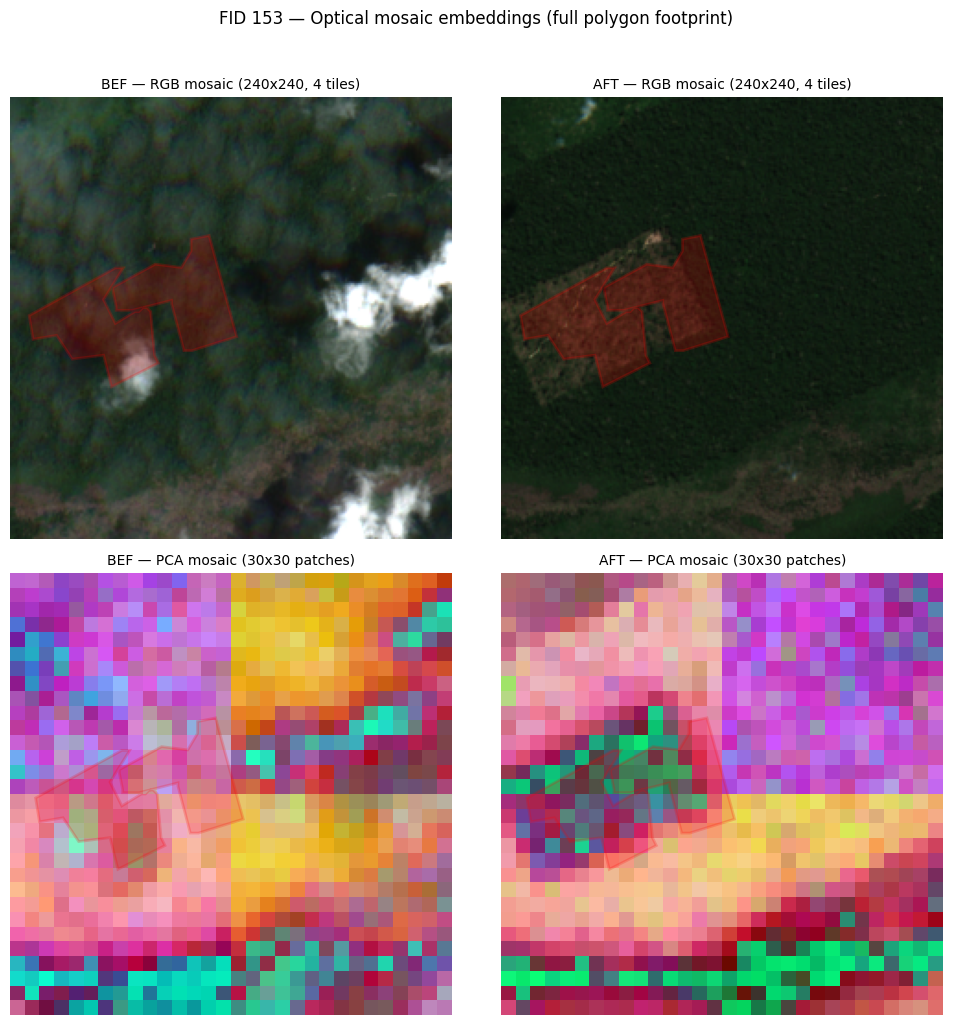

In [ ]:
# Run mosaic extraction for the chosen FID across all 3 windows (optical)
print("Loading optical model...")
model_opt = load_croma_model(['optical'])

mosaic_optical = {}
for window in ['evt', 'bef', 'aft']:
    image_ids = list_image_ids(FID, 's2_l2a', window)
    if not image_ids:
        continue
    image_id = image_ids[0]  # first acquisition in this window
    res = extract_polygon_tokens(model_opt, FID, 's2_l2a', window, image_id,
                                 modality='optical', band_indices=CROMA_S2_BAND_INDICES)
    if res is None:
        continue
    mosaic_optical[window] = res
    print(f"  {window}: image_id={image_id[:25]}..., n_tiles={res['n_tiles']}, "
          f"mosaic={res['mosaic_rows']}x{res['mosaic_cols']} tiles "
          f"({res['data'].shape[1]}x{res['data'].shape[2]} px)")

del model_opt
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ── PCA viz on the mosaic, ignoring NaN cells ──
windows_with_data = list(mosaic_optical.keys())
all_tokens = np.concatenate(
    [mosaic_optical[w]['tokens'].reshape(-1, EMBED_DIM) for w in windows_with_data])
valid = ~np.isnan(all_tokens).any(axis=1)
pca = PCA(n_components=3).fit(all_tokens[valid])
print(f"\nPCA explained variance: {pca.explained_variance_ratio_}")

fig, axes = plt.subplots(2, len(windows_with_data), figsize=(5 * len(windows_with_data), 10))
if len(windows_with_data) == 1:
    axes = axes[:, np.newaxis]

for col_i, window in enumerate(windows_with_data):
    res = mosaic_optical[window]
    data = res['data']
    tokens = res['tokens']
    mtrans = res['transform']
    mcrs = res['crs']
    th, tw = tokens.shape[:2]
    ph, pw = data.shape[1], data.shape[2]

    # Row 1: RGB mosaic (B4=3, B3=2, B2=1). NaN -> 0 for display.
    ax_rgb = axes[0, col_i]
    rgb = data[[3, 2, 1]].transpose(1, 2, 0).copy()
    rgb = np.clip(rgb / 3000, 0, 1)
    rgb[np.isnan(rgb)] = 0
    ax_rgb.imshow(rgb)
    add_polygon_overlay(ax_rgb, FID, mtrans, mcrs, ph)
    ax_rgb.set_title(f"{window.upper()} — RGB mosaic ({ph}x{pw}, {res['n_tiles']} tiles)", fontsize=10)
    ax_rgb.axis("off")

    # Row 2: PCA tokens. NaN cells displayed as gray.
    ax_pca = axes[1, col_i]
    flat = tokens.reshape(-1, EMBED_DIM)
    valid_mask = ~np.isnan(flat).any(axis=1)
    pca_rgb = np.full((flat.shape[0], 3), np.nan, dtype=np.float32)
    pca_rgb[valid_mask] = pca.transform(flat[valid_mask])
    pca_rgb = pca_rgb.reshape(th, tw, 3)
    for c in range(3):
        ch = pca_rgb[:, :, c]
        vmin = np.nanmin(ch); vmax = np.nanmax(ch)
        pca_rgb[:, :, c] = (ch - vmin) / (vmax - vmin + 1e-10)
    pca_rgb_disp = np.where(np.isnan(pca_rgb), 0.5, pca_rgb)
    ax_pca.imshow(pca_rgb_disp, interpolation='nearest')
    add_polygon_overlay_on_grid(ax_pca, FID, mtrans, mcrs, PATCH_SIZE)
    ax_pca.set_title(f"{window.upper()} — PCA mosaic ({th}x{tw} patches)", fontsize=10)
    ax_pca.axis("off")

fig.suptitle(f"FID {FID} — Optical mosaic embeddings (full polygon footprint)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 9.1 Cosine similarity on mosaic (full polygon footprint)

Per-patch cosine similarity between mosaic embeddings of different windows, covering the
entire polygon. NaN cells (positions outside any window's mosaic) propagate as NaN and
are shown in light gray.

Same colormap conventions as section 5:
- Top row (`RdYlGn`, 0.5–1.0): green = no change, red = changed.
- Bottom row (`hot`, 0–0.5): bright = changed, dark = no change.

In [ ]:
# Cosine similarity on the mosaic, comparing windows over the full polygon footprint.
# Different windows may have slightly different mosaic shapes (if downloads were partial),
# so we first align all window mosaics into a common global grid.

def align_mosaics(mosaics):
    """Re-place each window's tokens into a common global grid using absolute coords.
    Cells outside a window's mosaic stay NaN."""
    info = {w: {
        'x0': res['transform'].c, 'y0': res['transform'].f,
        'n_rows': res['mosaic_rows'], 'n_cols': res['mosaic_cols'],
    } for w, res in mosaics.items()}

    g_x0 = min(i['x0'] for i in info.values())
    g_y0 = max(i['y0'] for i in info.values())
    g_xmax = max(i['x0'] + i['n_cols'] * TILE_SIZE_M for i in info.values())
    g_ymin = min(i['y0'] - i['n_rows'] * TILE_SIZE_M for i in info.values())
    n_rows_g = int(round((g_y0 - g_ymin) / TILE_SIZE_M))
    n_cols_g = int(round((g_xmax - g_x0) / TILE_SIZE_M))

    aligned = {}
    for w, res in mosaics.items():
        col_off = int(round((info[w]['x0'] - g_x0) / TILE_SIZE_M))
        row_off = int(round((g_y0 - info[w]['y0']) / TILE_SIZE_M))
        tokens_g = np.full((n_rows_g * GRID_SIZE, n_cols_g * GRID_SIZE, EMBED_DIM),
                           np.nan, dtype=np.float32)
        h, w_ = res['tokens'].shape[:2]
        ty, tx = row_off * GRID_SIZE, col_off * GRID_SIZE
        tokens_g[ty:ty + h, tx:tx + w_, :] = res['tokens']
        aligned[w] = tokens_g

    g_transform = rasterio.transform.from_origin(g_x0, g_y0, 10.0, 10.0)
    g_crs = next(iter(mosaics.values()))['crs']
    return aligned, g_transform, g_crs


aligned_tokens, mosaic_global_transform, mosaic_crs = align_mosaics(mosaic_optical)
print(f"Aligned mosaic shape (patches): {next(iter(aligned_tokens.values())).shape[:2]}")

# Window pairs to compare
mosaic_comparisons = []
for a, b in [('evt', 'bef'), ('evt', 'aft'), ('bef', 'aft')]:
    if a in aligned_tokens and b in aligned_tokens:
        mosaic_comparisons.append((f"{a} vs {b}", a, b))

if mosaic_comparisons:
    # ─── PASE 1: calcular sims y resumir estadísticas (filtrando NaN) ───
    mosaic_sims = {}
    print("=" * 82)
    print(f"{'Pair':<14} {'min':>8} {'p1':>8} {'p5':>8} {'p50':>8} {'p95':>8} {'max':>8}  {'mean':>8}  {'n_valid':>8}")
    print("=" * 82)
    for title, w1, w2 in mosaic_comparisons:
        # cosine_similarity_map propagates NaN: any NaN in either input -> NaN result
        sim = cosine_similarity_map(aligned_tokens[w1], aligned_tokens[w2])
        mosaic_sims[(w1, w2)] = sim
        valid = sim[~np.isnan(sim)]
        if valid.size == 0:
            print(f"{title:<14} (no valid cells)")
            continue
        print(f"{title:<14} "
              f"{valid.min():>8.3f} "
              f"{np.percentile(valid, 1):>8.3f} "
              f"{np.percentile(valid, 5):>8.3f} "
              f"{np.percentile(valid, 50):>8.3f} "
              f"{np.percentile(valid, 95):>8.3f} "
              f"{valid.max():>8.3f}  "
              f"{valid.mean():>8.3f}  "
              f"{valid.size:>8d}")

    # Calibración GLOBAL (sobre celdas válidas de todos los pares)
    all_valid = np.concatenate([s[~np.isnan(s)] for s in mosaic_sims.values()])
    vmin_sim = float(np.percentile(all_valid, 1))
    vmax_sim = 1.0
    vmin_change = 1 - vmax_sim
    vmax_change = 1 - vmin_sim
    print(f"\nEscala común calibrada (p1 sobre celdas válidas):")
    print(f"  Cosine similarity: [{vmin_sim:.3f}, {vmax_sim:.3f}]")
    print(f"  Change magnitude:  [{vmin_change:.3f}, {vmax_change:.3f}]")

    # ─── PASE 2: visualizar con escala calibrada ───
    n_comp = len(mosaic_comparisons)
    fig, axes = plt.subplots(2, n_comp, figsize=(5 * n_comp, 10))
    if n_comp == 1:
        axes = axes[:, np.newaxis]

    cmap_sim = plt.get_cmap('RdYlGn').copy(); cmap_sim.set_bad('lightgray')
    cmap_hot = plt.get_cmap('hot').copy();    cmap_hot.set_bad('lightgray')

    for col_i, (title, w1, w2) in enumerate(mosaic_comparisons):
        sim = mosaic_sims[(w1, w2)]

        ax = axes[0, col_i]
        im = ax.imshow(np.ma.masked_invalid(sim), cmap=cmap_sim,
                       vmin=vmin_sim, vmax=vmax_sim, interpolation='nearest')
        add_polygon_overlay_on_grid(ax, FID, mosaic_global_transform, mosaic_crs, PATCH_SIZE)
        ax.set_title(f"{title}\nCosine similarity (mosaic)\n[{vmin_sim:.2f}, {vmax_sim:.2f}]", fontsize=10)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)

        ax2 = axes[1, col_i]
        change = 1 - sim
        im2 = ax2.imshow(np.ma.masked_invalid(change), cmap=cmap_hot,
                         vmin=vmin_change, vmax=vmax_change, interpolation='nearest')
        add_polygon_overlay_on_grid(ax2, FID, mosaic_global_transform, mosaic_crs, PATCH_SIZE)
        ax2.set_title(f"{title}\nChange magnitude (mosaic)\n[{vmin_change:.2f}, {vmax_change:.2f}]", fontsize=10)
        ax2.axis('off')
        plt.colorbar(im2, ax=ax2, fraction=0.046)

    fig.suptitle(f"FID {FID} — Per-patch change on mosaic (full polygon, escala calibrada)",
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Need at least two windows in mosaic_optical to compare")


## 10. Joint mode (S1 + S2) with 6-day pairing

Adapted from `visualize_croma_embeddings.find_paired_tiles`: for each (window, tile_idx),
each S2 acquisition is matched to the closest S1 acquisition on/before the S2 date and
within `MAX_DAY_GAP` days. Pairs that exceed the gap are dropped.

The joint CROMA model fuses both modalities through a cross-attention encoder, producing
fused 15×15 patch tokens per pair. Pairs are then stitched per (window, S2 image_id) into a
mosaic, like in section 9.

In [ ]:
from datetime import datetime

MAX_DAY_GAP = 6


def parse_date_from_image_id(image_id, sensor):
    if sensor == 's2':
        return datetime.strptime(image_id[:8], '%Y%m%d')
    return datetime.strptime(image_id[17:25], '%Y%m%d')


def find_paired_tiles_fid(fid, max_day_gap=MAX_DAY_GAP, windows=('evt', 'bef')):
    """Adapt of `visualize_croma_embeddings.find_paired_tiles` to the notebook's
    TILES_DIR layout. For each (window, tile_idx), pair every S2 tile to the
    closest S1 tile acquired on/before the S2 date, within `max_day_gap` days.
    Pairs that exceed the gap are dropped (NOT kept as unpaired)."""
    s2_tiles = {}
    s1_tiles = {}
    for window in windows:
        for product, sensor, store in [('s2_l2a', 's2', s2_tiles),
                                        ('s1_grd', 's1', s1_tiles)]:
            win_dir = os.path.join(TILES_DIR, product, f"fid_{fid}", window)
            if not os.path.isdir(win_dir):
                continue
            for image_id in sorted(os.listdir(win_dir)):
                try:
                    date = parse_date_from_image_id(image_id, sensor)
                except ValueError:
                    continue
                for tile_path in sorted(glob.glob(
                        os.path.join(win_dir, image_id, "tile_*.tif"))):
                    tile_idx = os.path.basename(tile_path).replace(".tif", "")
                    key = (window, tile_idx)
                    store.setdefault(key, []).append((image_id, date, tile_path))

    paired_s1 = set()
    records = []
    for key in sorted(set(s2_tiles.keys()) | set(s1_tiles.keys())):
        window, tile_idx = key
        s2_list = sorted(s2_tiles.get(key, []), key=lambda x: x[1])
        s1_list = sorted(s1_tiles.get(key, []), key=lambda x: x[1])
        for s2_id, s2_date, s2_path in s2_list:
            best = None
            for s1_id, s1_date, s1_path in s1_list:
                if (window, tile_idx, s1_id) in paired_s1:
                    continue
                if s1_date > s2_date:
                    continue
                gap = (s2_date - s1_date).days
                if gap > max_day_gap:
                    continue
                if best is None or gap < best['gap']:
                    best = {'s1_id': s1_id, 's1_path': s1_path, 'gap': gap}
            if best is not None:
                paired_s1.add((window, tile_idx, best['s1_id']))
                records.append({
                    'fid': fid, 'window': window, 'tile_idx': tile_idx,
                    's2_id': s2_id, 's2_path': s2_path,
                    's1_id': best['s1_id'], 's1_path': best['s1_path'],
                    'day_gap': best['gap'],
                })
    return records


pairs = find_paired_tiles_fid(FID, max_day_gap=MAX_DAY_GAP, windows=('evt', 'bef'))
print(f"FID {FID}: {len(pairs)} paired (S2,S1) tiles within {MAX_DAY_GAP} days "
      f"(windows: evt, bef)")
for r in pairs[:8]:
    print(f"  [{r['window']}/{r['tile_idx']}] gap={r['day_gap']}d  "
          f"S2={r['s2_id'][:25]}  S1={r['s1_id'][17:25]}")
if len(pairs) > 8:
    print(f"  ... ({len(pairs) - 8} more)")

FID 153: 8 paired (S2,S1) tiles within 6 days (windows: evt, bef)
  [bef/tile_0] gap=0d  S2=20230214T142711_20230214T  S1=20230214
  [bef/tile_0] gap=5d  S2=20230420T142719_20230420T  S1=20230415
  [bef/tile_1] gap=0d  S2=20230214T142711_20230214T  S1=20230214
  [bef/tile_1] gap=5d  S2=20230420T142719_20230420T  S1=20230415
  [bef/tile_2] gap=0d  S2=20230214T142711_20230214T  S1=20230214
  [bef/tile_2] gap=5d  S2=20230420T142719_20230420T  S1=20230415
  [bef/tile_3] gap=0d  S2=20230214T142711_20230214T  S1=20230214
  [bef/tile_3] gap=5d  S2=20230420T142719_20230420T  S1=20230415


In [ ]:
# Joint mode: fused S1+S2 patch tokens stitched into a mosaic per (window, S2 image_id).
print("Loading joint model...")
model_joint = load_croma_model(['optical', 'sar'])
print("Joint model named children:")
for _n, _m in model_joint.named_children():
    print(f"  {_n}: {type(_m).__name__}")

# Locate the joint cross-attention encoder (name varies across torchgeo versions)
joint_encoder = getattr(model_joint, 'joint_encoder', None)
if joint_encoder is None:
    for _n, _m in model_joint.named_children():
        if 'joint' in _n.lower():
            joint_encoder = _m
            break
if joint_encoder is None:
    raise RuntimeError("Could not locate joint encoder in CROMA joint model")


def encode_pairs_joint(model, s2_batch, s1_batch):
    """Joint forward pass on N paired (S2, S1) tiles, normalized JOINTLY across
    all N pairs (CROMA recipe over the batch). Returns (N, 15, 15, 768)."""
    x_s2 = normalize(torch.from_numpy(s2_batch)).to(device)        # stats over all S2 tiles
    x_s1 = normalize(torch.from_numpy(s1_batch)).to(device)        # stats over all S1 tiles
    captured = {}

    def hook(module, inp, out):
        captured['tokens'] = out

    h = joint_encoder.register_forward_hook(hook)
    with torch.no_grad():
        _ = model(x_optical=x_s2, x_sar=x_s1)
    h.remove()

    out = captured['tokens']
    if isinstance(out, tuple):
        out = out[0]
    tokens = out.cpu().numpy()
    if tokens.ndim == 2:
        tokens = tokens[None]
    expected = GRID_SIZE * GRID_SIZE
    if tokens.shape[1] == expected + 1:
        tokens = tokens[:, 1:]
    return tokens.reshape(-1, GRID_SIZE, GRID_SIZE, EMBED_DIM)


# Group pairs by (window, s2_image_id) so each mosaic = one S2 acquisition
from collections import defaultdict
pairs_by_acq = defaultdict(list)
for r in pairs:
    pairs_by_acq[(r['window'], r['s2_id'])].append(r)

# For visualization, take the first S2 acquisition per window that has pairs
joint_mosaic = {}
for window in ['evt', 'bef']:
    acq_keys = sorted(k for k in pairs_by_acq if k[0] == window)
    if not acq_keys:
        continue
    key = acq_keys[0]
    recs = pairs_by_acq[key]

    transforms = []
    for r in recs:
        with rasterio.open(r['s2_path']) as src:
            transforms.append(src.transform)
    with rasterio.open(recs[0]['s2_path']) as src:
        crs = src.crs
    x0, y0, n_rows, n_cols = build_mosaic_origin(transforms)
    mosaic_transform = rasterio.transform.from_origin(x0, y0, 10.0, 10.0)

    data_mosaic = np.full((12, n_rows * TILE_SIZE, n_cols * TILE_SIZE), np.nan, dtype=np.float32)
    tokens_mosaic = np.full((n_rows * GRID_SIZE, n_cols * GRID_SIZE, EMBED_DIM), np.nan, dtype=np.float32)

    # Load ALL paired tiles first, then normalize jointly and encode in one pass
    loaded = []
    for r in recs:
        s2_data, s2_t, _ = load_tile(r['s2_path'], band_indices=CROMA_S2_BAND_INDICES)
        s1_data, _, _ = load_tile(r['s1_path'])
        loaded.append({'r': r, 's2_data': s2_data, 's1_data': s1_data, 's2_t': s2_t})

    s2_batch = np.stack([item['s2_data'] for item in loaded], axis=0).astype(np.float32)
    s1_batch = np.stack([item['s1_data'] for item in loaded], axis=0).astype(np.float32)
    tokens_batch = encode_pairs_joint(model_joint, s2_batch, s1_batch)   # (N, 15, 15, 768)

    for item, tokens in zip(loaded, tokens_batch):
        row, col = tile_grid_position(item['s2_t'], x0, y0)
        py, px = row * TILE_SIZE, col * TILE_SIZE
        ty, tx = row * GRID_SIZE, col * GRID_SIZE
        data_mosaic[:, py:py + TILE_SIZE, px:px + TILE_SIZE] = item['s2_data']
        tokens_mosaic[ty:ty + GRID_SIZE, tx:tx + GRID_SIZE, :] = tokens

    joint_mosaic[window] = {
        'data': data_mosaic, 'tokens': tokens_mosaic,
        'transform': mosaic_transform, 'crs': crs,
        's2_id': key[1], 'n_pairs': len(recs),
        'mosaic_rows': n_rows, 'mosaic_cols': n_cols,
    }
    print(f"  {window}: S2={key[1][:25]}..., {len(recs)} paired tiles -> "
          f"mosaic {n_rows}x{n_cols} tiles "
          f"(median day_gap={int(np.median([r['day_gap'] for r in recs]))}d)")

del model_joint
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ── PCA viz of joint mosaic ──
if joint_mosaic:
    windows_with_data = list(joint_mosaic.keys())
    all_tokens = np.concatenate(
        [joint_mosaic[w]['tokens'].reshape(-1, EMBED_DIM) for w in windows_with_data])
    valid = ~np.isnan(all_tokens).any(axis=1)
    pca = PCA(n_components=3).fit(all_tokens[valid])
    print(f"\nJoint PCA explained variance: {pca.explained_variance_ratio_}")

    fig, axes = plt.subplots(2, len(windows_with_data), figsize=(5 * len(windows_with_data), 10))
    if len(windows_with_data) == 1:
        axes = axes[:, np.newaxis]

    for col_i, window in enumerate(windows_with_data):
        res = joint_mosaic[window]
        data = res['data']
        tokens = res['tokens']
        mtrans = res['transform']
        mcrs = res['crs']
        th, tw = tokens.shape[:2]
        ph, pw = data.shape[1], data.shape[2]

        ax_rgb = axes[0, col_i]
        rgb = data[[3, 2, 1]].transpose(1, 2, 0).copy()
        rgb = np.clip(rgb / 3000, 0, 1)
        rgb[np.isnan(rgb)] = 0
        ax_rgb.imshow(rgb)
        add_polygon_overlay(ax_rgb, FID, mtrans, mcrs, ph)
        ax_rgb.set_title(f"{window.upper()} — S2 mosaic ({ph}x{pw}, {res['n_pairs']} pairs)", fontsize=10)
        ax_rgb.axis("off")

        ax_pca = axes[1, col_i]
        flat = tokens.reshape(-1, EMBED_DIM)
        m = ~np.isnan(flat).any(axis=1)
        pca_rgb = np.full((flat.shape[0], 3), np.nan, dtype=np.float32)
        pca_rgb[m] = pca.transform(flat[m])
        pca_rgb = pca_rgb.reshape(th, tw, 3)
        for c in range(3):
            ch = pca_rgb[:, :, c]
            vmin = np.nanmin(ch); vmax = np.nanmax(ch)
            pca_rgb[:, :, c] = (ch - vmin) / (vmax - vmin + 1e-10)
        pca_rgb_disp = np.where(np.isnan(pca_rgb), 0.5, pca_rgb)
        ax_pca.imshow(pca_rgb_disp, interpolation='nearest')
        add_polygon_overlay_on_grid(ax_pca, FID, mtrans, mcrs, PATCH_SIZE)
        ax_pca.set_title(f"{window.upper()} — Joint PCA ({th}x{tw} patches)", fontsize=10)
        ax_pca.axis("off")

    fig.suptitle(f"FID {FID} — Joint S1+S2 mosaic embeddings ({MAX_DAY_GAP}-day pairing)",
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print(f"No joint pairs found within the {MAX_DAY_GAP}-day window.")

### 10.1 Cosine similarity on joint mosaic (full polygon footprint)

Per-patch cosine similarity on the **fused S1+S2** embeddings between `evt` and `bef`,
covering the entire polygon. NaN cells (positions without a paired tile within
`MAX_DAY_GAP` days) are shown in light gray.

Same colormap conventions as section 9.1:
- Top row (`RdYlGn`, 0.5–1.0): green = no change, red = changed.
- Bottom row (`hot`, 0–0.5): bright = changed, dark = no change.

In [ ]:
# Cosine similarity on the joint S1+S2 mosaic, comparing windows over the full polygon
# footprint. Reuses align_mosaics + cosine_similarity_map from section 9.1.
if joint_mosaic and len(joint_mosaic) >= 2:
    aligned_joint, joint_global_transform, joint_crs = align_mosaics(joint_mosaic)
    print(f"Aligned joint mosaic shape (patches): {next(iter(aligned_joint.values())).shape[:2]}")

    joint_comparisons = []
    for a, b in [('evt', 'bef')]:  # joint pairing only uses evt+bef
        if a in aligned_joint and b in aligned_joint:
            joint_comparisons.append((f"{a} vs {b}", a, b))

    if joint_comparisons:
        # ─── PASE 1: calcular sims y resumir estadísticas (filtrando NaN) ───
        joint_sims = {}
        print("=" * 82)
        print(f"{'Pair':<14} {'min':>8} {'p1':>8} {'p5':>8} {'p50':>8} {'p95':>8} {'max':>8}  {'mean':>8}  {'n_valid':>8}")
        print("=" * 82)
        for title, w1, w2 in joint_comparisons:
            sim = cosine_similarity_map(aligned_joint[w1], aligned_joint[w2])
            joint_sims[(w1, w2)] = sim
            valid = sim[~np.isnan(sim)]
            if valid.size == 0:
                print(f"{title:<14} (no valid cells)")
                continue
            print(f"{title:<14} "
                  f"{valid.min():>8.3f} "
                  f"{np.percentile(valid, 1):>8.3f} "
                  f"{np.percentile(valid, 5):>8.3f} "
                  f"{np.percentile(valid, 50):>8.3f} "
                  f"{np.percentile(valid, 95):>8.3f} "
                  f"{valid.max():>8.3f}  "
                  f"{valid.mean():>8.3f}  "
                  f"{valid.size:>8d}")

        # Calibración GLOBAL
        all_valid = np.concatenate([s[~np.isnan(s)] for s in joint_sims.values()])
        vmin_sim = float(np.percentile(all_valid, 1))
        vmax_sim = 1.0
        vmin_change = 1 - vmax_sim
        vmax_change = 1 - vmin_sim
        print(f"\nEscala común calibrada (p1 sobre celdas válidas):")
        print(f"  Cosine similarity: [{vmin_sim:.3f}, {vmax_sim:.3f}]")
        print(f"  Change magnitude:  [{vmin_change:.3f}, {vmax_change:.3f}]")

        # ─── PASE 2: visualizar con escala calibrada ───
        n_comp = len(joint_comparisons)
        fig, axes = plt.subplots(2, n_comp, figsize=(5 * n_comp, 10))
        if n_comp == 1:
            axes = axes[:, np.newaxis]

        cmap_sim = plt.get_cmap('RdYlGn').copy(); cmap_sim.set_bad('lightgray')
        cmap_hot = plt.get_cmap('hot').copy();    cmap_hot.set_bad('lightgray')

        for col_i, (title, w1, w2) in enumerate(joint_comparisons):
            sim = joint_sims[(w1, w2)]

            ax = axes[0, col_i]
            im = ax.imshow(np.ma.masked_invalid(sim), cmap=cmap_sim,
                           vmin=vmin_sim, vmax=vmax_sim, interpolation='nearest')
            add_polygon_overlay_on_grid(ax, FID, joint_global_transform, joint_crs, PATCH_SIZE)
            ax.set_title(f"{title}\nCosine similarity (joint mosaic)\n[{vmin_sim:.2f}, {vmax_sim:.2f}]", fontsize=10)
            ax.axis('off')
            plt.colorbar(im, ax=ax, fraction=0.046)

            ax2 = axes[1, col_i]
            change = 1 - sim
            im2 = ax2.imshow(np.ma.masked_invalid(change), cmap=cmap_hot,
                             vmin=vmin_change, vmax=vmax_change, interpolation='nearest')
            add_polygon_overlay_on_grid(ax2, FID, joint_global_transform, joint_crs, PATCH_SIZE)
            ax2.set_title(f"{title}\nChange magnitude (joint mosaic)\n[{vmin_change:.2f}, {vmax_change:.2f}]", fontsize=10)
            ax2.axis('off')
            plt.colorbar(im2, ax=ax2, fraction=0.046)

        fig.suptitle(f"FID {FID} — Joint S1+S2 per-patch change on mosaic "
                     f"({MAX_DAY_GAP}-day pairing, full polygon, escala calibrada)", fontsize=12, y=1.02)
        plt.tight_layout()
        plt.show()
    else:
        print("Need joint_mosaic with both evt and bef windows to compare")
else:
    print("Need joint_mosaic for at least 2 windows (evt and bef) to compare")
